In [1]:
import numpy as np

def sample_W_with_target_fro_distance(
    d: int,
    target_dist: float,
) -> np.ndarray:
    E = np.random.rand(d, d)
    fro_E = np.linalg.norm(E, ord="fro")
    E /= fro_E
    W = np.eye(d) + target_dist * E
    return W


def generate_data(n, d, W_fro_dist=0.1, sigma=0.0, seed=0):
    np.random.seed(seed)

    # X_ij ~ N(0, 1/d)
    X = np.random.randn(n, d)/ np.sqrt(d)

    # Construct W with controlled ||W - I||_F
    W = sample_W_with_target_fro_distance(d, W_fro_dist)

    Y_true = X @ W
    Y_noisy = Y_true + sigma * np.random.standard_normal((n, d))

    perm = np.random.permutation(n)
    P = np.eye(n)[perm]          # permutation matrix
    Y_obs = P @ Y_noisy

    return X, Y_obs, W, perm


def fro_norm_W_minus_I(W: np.ndarray) -> float:
    W = np.asarray(W)
    if W.ndim != 2 or W.shape[0] != W.shape[1]:
        raise ValueError(f"W must be square, got {W.shape}")
    I = np.eye(W.shape[0], dtype=W.dtype)
    return float(np.linalg.norm(W - I, ord="fro"))


# Example
n, d = 100, 100
X, Y_obs, W, perm = generate_data(n, d, W_fro_dist=5.9, sigma=0.00, seed=1234)
print("||W - I||_F =", fro_norm_W_minus_I(W))


||W - I||_F = 5.9


In [2]:
import sys
import torch
from typing import Dict, Tuple, List, Optional
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from cellot.models.cellot import load_networks, compute_loss_f, compute_loss_g

from sklearn.metrics.pairwise import rbf_kernel

def run_cellot_pair(train_pre: np.ndarray, train_post: np.ndarray,
                    test_pre: np.ndarray, test_post: np.ndarray,
                    layers: Optional[List[int]] = [8],
                    n_epochs: int = 1000,
                    lr: float = 1e-5,
                    gamma: Optional[float] = None,
                    feature_subset: Optional[List[int]] = None,) -> Dict:
    
    device = 'cuda'
    print(f"VERS torch={torch.__version__} (CellOT), device={device}", file=sys.stderr, flush=True)


    # Apply feature subset if specified
    if feature_subset is not None:
        print(f"Using feature subset of size {len(feature_subset)}", file=sys.stderr, flush=True)
        train_pre = train_pre[:, feature_subset]
        train_post = train_post[:, feature_subset]
        test_pre = test_pre[:, feature_subset]
        test_post = test_post[:, feature_subset]

    # Preprocess: standardize jointly and optionally apply PCA for stability
    X_all = np.vstack([train_pre, train_post])
    scaler = StandardScaler()
    X_all_s = scaler.fit_transform(X_all)
    d = X_all_s.shape[1]
    pca_dims = min(1000, d)
    if pca_dims < d:
        pca = PCA(n_components=pca_dims, svd_solver='full', random_state=42)
        X_all_p = pca.fit_transform(X_all_s)
        tr_pre_p = X_all_p[:len(train_pre)]
        tr_post_p = X_all_p[len(train_pre):]
        te_pre_p = pca.transform(scaler.transform(test_pre))
        use_pca = True
    else:
        tr_pre_p = X_all_s[:len(train_pre)]
        tr_post_p = X_all_s[len(train_pre):]
        te_pre_p = scaler.transform(test_pre)
        use_pca = False

    # Networks - Using official CellOT configuration
    input_dim = tr_pre_p.shape[1]
    config = {
        'model': {
            'name': 'cellot',
            'hidden_units': layers,
            'kernel_init_fxn': {'name': 'uniform', 'a': -0.01, 'b': 0.01},
            'activation': 'relu',
            'softplus_W_kernels': True,
            'f': {},
            'g': {}
        }
    }
    f, g = load_networks(config, input_dim=input_dim)
    f = f.to(device).float()
    g = g.to(device).float()

    # Data tensors
    src = torch.tensor(tr_pre_p, dtype=torch.float32, device=device)
    tgt = torch.tensor(tr_post_p, dtype=torch.float32, device=device)
    te_src = torch.tensor(te_pre_p, dtype=torch.float32, device=device)


    optim_f = torch.optim.Adam(f.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)
    optim_g = torch.optim.Adam(g.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)

    # No schedulers in official config
    # n_epochs = 1200  # More epochs for better convergence
    n_epochs = n_epochs + 1  
    # Training loop following official CellOT implementation
    f.train(); g.train()
    batch_size = 256  # Official config
    n_inner_iters = 10  # Official config

    history = {'epoch': [], 'train_mmd': [], 'test_mmd': []}
    for epoch in range(n_epochs):
        f.train(); g.train()
        perm_t = torch.randperm(len(tgt), device=device)[:batch_size]
        yt = tgt[perm_t]
        
        # Multiple g updates per iteration (official implementation)
        for _ in range(n_inner_iters):
            perm_s = torch.randperm(len(src), device=device)[:batch_size]
            xs = src[perm_s].detach().clone().requires_grad_(True)
            
            optim_g.zero_grad()
            g_loss = compute_loss_g(f, g, xs).mean()
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(g.parameters(), max_norm=0.5)
            optim_g.step()
        
        # Single f update (official implementation)
        perm_s = torch.randperm(len(src), device=device)[:batch_size]
        xs = src[perm_s].detach().clone().requires_grad_(True)
        
        optim_f.zero_grad()
        f_loss = compute_loss_f(f, g, xs, yt).mean()
        f_loss.backward()
        optim_f.step()
        
        # Clamp weights for f (official implementation)
        if hasattr(f, 'clamp_w'):
            f.clamp_w()
        
         

    # Inference (CellOT transport requires gradients for autodiff)
    f.eval(); g.eval()
    # CellOT needs gradients even in eval mode for transport computation
    te_src_for_transport = te_src.detach().clone().requires_grad_(True)
    te_tx = g.transport(te_src_for_transport).detach().cpu().numpy()

    # Inverse preprocess
    if use_pca:
        te_tx_inv = scaler.inverse_transform(pca.inverse_transform(te_tx))
    else:
        te_tx_inv = scaler.inverse_transform(te_tx)
    # Final evaluation

    return te_tx_inv
    

def mmd_distance(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased MMD^2 estimator using Gaussian (RBF) kernel, sklearn backend.

    Args:
        X: (n_samples, n_features) first sample
        Y: (m_samples, n_features) second sample
        gamma: RBF kernel bandwidth; if None, uses median heuristic

    Returns:
        Unbiased MMD^2 value
    """
    n = X.shape[0]
    m = Y.shape[0]

    # Kernel matrices
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    # Unbiased: exclude diagonal entries
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (n * (n - 1)) if n > 1 else 0.0
    term_yy = Kyy.sum() / (m * (m - 1)) if m > 1 else 0.0
    term_xy = 2.0 * Kxy.mean()

    mmd2 = term_xx + term_yy - term_xy
    mmd2 = max(mmd2, 0.0)  # Numerical stability
    return float(mmd2)


Processing dims:   0%|                                                                                                                                                                                                                     | 0/10 [00:00<?, ?it/s]VERS torch=2.8.0+cu128 (CellOT), device=cuda
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
VERS torch=2.8.0+cu128 (CellOT), device=cuda


Dim: 100, Dev: 0.0, MMD: 0.0010


VERS torch=2.8.0+cu128 (CellOT), device=cuda


Dim: 100, Dev: 0.0, MMD: 0.0011


VERS torch=2.8.0+cu128 (CellOT), device=cuda


...

Dim: 10, Dev: 200.0, MMD: 0.9920


VERS torch=2.8.0+cu128 (CellOT), device=cuda


Dim: 10, Dev: 200.0, MMD: 0.9979


Processing dims: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [2:25:42<00:00, 874.29s/it]

Dim: 10, Dev: 200.0, MMD: 0.9982


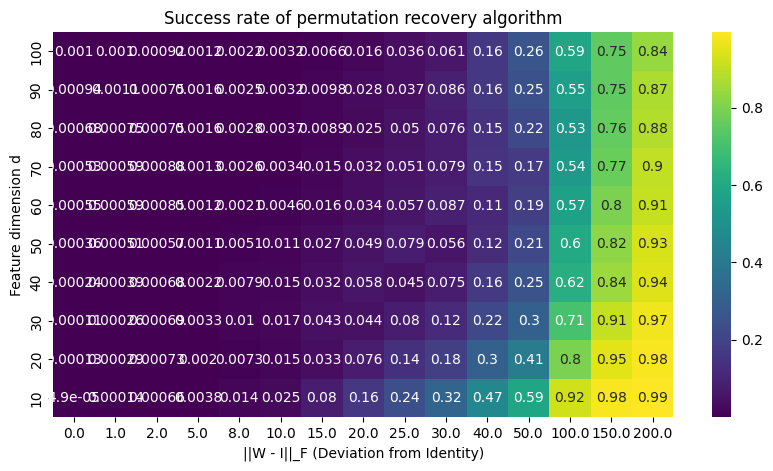

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np

# -----------------------------
# Experiment Grid
# -----------------------------
dims = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]  # reduced for runtime
A_devs = [0.0, 1.0, 2.0, 5.0, 8.0, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0, 50.0, 100.0, 150.0, 200.0]
trials = 5  # reduced for speed
n = 100  # reduced for speed

results = np.zeros((len(dims), len(A_devs)))

for i, d in enumerate(tqdm(dims, desc="Processing dims")):
    for j, dev in enumerate(A_devs):
        accs = []
        for _ in range(trials):
            X, Y_obs, A_true, perm_true = generate_data(n=n, d=d, W_fro_dist=dev, sigma=0.0, seed=i+j+_+123)
            A_hat = run_cellot_pair(X, Y_obs, X, Y_obs,)
            accs.append(mmd_distance(A_hat, Y_obs, gamma=0.01))  # success if MMD is small
            print(f"Dim: {d}, Dev: {dev:.1f}, MMD: {accs[-1]:.4f}")
        results[i, j] = np.mean(accs)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,5))
sns.heatmap(results, xticklabels=A_devs, yticklabels=dims, annot=True, cmap="viridis")
plt.xlabel("||W - I||_F (Deviation from Identity)")
plt.ylabel("Feature dimension d")
plt.title("Success rate of permutation recovery algorithm")
plt.show()


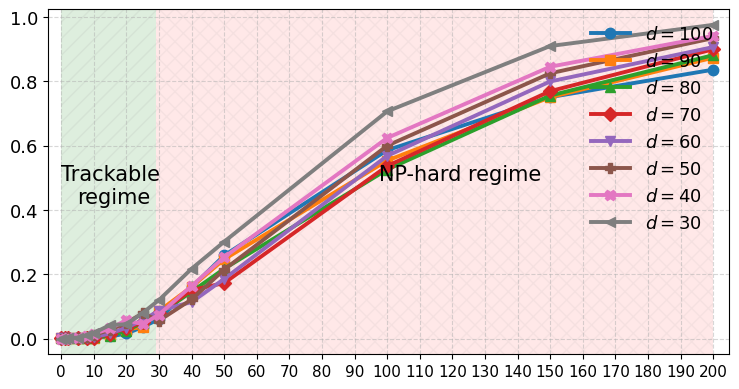

Saved: com_cellot_near_identity_permutation_recovery_d30_d100_ten_iteration_n100_final.pdf


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# REQUIRED INPUTS (you already have these)
#   A_devs: 1D array-like, values on x-axis (should span 0..100)
#   results: 2D array-like, shape = (num_d, len(A_devs))
#            rows correspond to d = 10,20,...,100 (or the reverse; see row_order)
# -----------------------------
x = np.asarray(A_devs, dtype=float)
results = np.asarray(results, dtype=float)

# -----------------------------
# CONFIG
# -----------------------------
d_values = np.arange(100, 9, -10)  # d = 10,20,...,100

# If your results rows are ordered as:
#   "ascending": row 0 -> d=10, row 1 -> d=20, ..., row 9 -> d=100
#   "descending": row 0 -> d=100, row 1 -> d=90, ..., row 9 -> d=10
row_order = "ascending"  # change to "descending" if needed

# vertical threshold line x = x0 (in [0, 100])
x0 =29.0  # <-- set your boundary here

# Define which side is "possible"
possible_side = "left"   # "left" means x <= x0 possible; "right" means x >= x0 possible

# Plot styling
lw = 2.8
ms = 7.5
markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '<', '>', '*']  # 10 distinct markers

# Output
fig_path = "com_cellot_near_identity_permutation_recovery_d30_d100_ten_iteration_n100_final.pdf"

# -----------------------------
# SANITY CHECKS
# -----------------------------
if results.ndim != 2:
    raise ValueError(f"`results` must be 2D, got shape {results.shape}.")
if x.ndim != 1:
    raise ValueError(f"`A_devs` must be 1D, got shape {x.shape}.")
if results.shape[0] != len(d_values):
    raise ValueError(
        f"`results` must have {len(d_values)} rows (for d=10..100), "
        f"but has {results.shape[0]} rows."
    )
if results.shape[1] != len(x):
    raise ValueError(
        f"`results` must have {len(x)} columns (same as len(A_devs)), "
        f"but has {results.shape[1]} columns."
    )

# align d_values with results row order
if row_order.lower() == "descending":
    d_plot = d_values[::-1]
else:
    d_plot = d_values

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(7.5, 4))
ax = plt.gca()

# Shade regions (different hatching so it’s visually distinct even in grayscale)
if possible_side.lower() == "left":
    ax.axvspan(0, x0, alpha=0.13, hatch='//',  facecolor="green", edgecolor='0.6', linewidth=0.0, zorder=0)
    ax.axvspan(x0, 200, alpha=0.09, hatch='xx', facecolor="red", edgecolor='0.6', linewidth=0.0, zorder=0)
    possible_label_x = 0.5 * x0
    impossible_label_x = x0 + 0.5 * (150 - x0)
    possible_text, impossible_text = "Trackable \nregime", "NP-hard regime"
else:
    ax.axvspan(0, x0, alpha=0.15, hatch='//',  facecolor="green", edgecolor='0.8', linewidth=0.0, zorder=0)
    ax.axvspan(x0, 200, alpha=0.05, hatch='xx', edgecolor='0.8', linewidth=0.0, zorder=0)
    possible_label_x = 0.5 * x0
    impossible_label_x = x0 + 0.5 * (150 - x0)
    possible_text, impossible_text = "Trackable \nregime", "NP-hard regime"

# Threshold line
# ax.axvline(x0, linestyle='--', linewidth=2.2, zorder=2)

# Curves for d=10..100
for i, d in enumerate(d_plot[:8]):
    # i+=1
    ax.plot(
        x, results[i, :],
        marker=markers[i % len(markers)],
        linewidth=lw,
        markersize=ms,
        label=rf"$d={d}$",
        zorder=3
    )

# Axes limits: x from 0 to 100 (as requested)
ax.set_xlim(-4, 205)
ax.set_xticks(np.arange(0, 201, 10))

# If you want fixed y-limits (uncomment if your recovery is in [0,1])
# ax.set_ylim(-0.05, 1.05)f

# Optional labels
# ax.set_xlabel(r"$\|W^\star - I_d\|_F$", fontsize=14)
# ax.set_ylabel("Permutation recovery rate", fontsize=14)

# Region labels (use axis transform so text stays near the top regardless of y-scale)
ax.text(possible_label_x+1.5, 0.55, possible_text, transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=15)
ax.text(impossible_label_x+33, 0.55, impossible_text, transform=ax.get_xaxis_transform(),
        ha="center", va="top", fontsize=15)

# Grid + legend
ax.grid(True, linestyle="--", alpha=0.5)

# Legend can get crowded; this keeps it readable
ax.legend(frameon=False, fontsize=13, loc="upper right", ncol=1, handlelength=2.2)

ax.tick_params(axis='x', which='major', labelsize=11)
ax.tick_params(axis='y', which='major', labelsize=13)

plt.tight_layout()
plt.savefig(fig_path, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path}")


In [5]:
print("A", A_devs)
i = 0
for row in results:
    print(d_values[i], "[" + "  ".join(f"{x:.2f}" for x in row) + "]")
    i += 1

A [0.0, 1.0, 2.0, 5.0, 8.0, 10.0, 15.0, 20.0, 25.0, 30.0, 40.0, 50.0, 100.0, 150.0, 200.0]
100 [0.00  0.00  0.00  0.00  0.00  0.00  0.01  0.02  0.04  0.06  0.16  0.26  0.59  0.75  0.84]
90 [0.00  0.00  0.00  0.00  0.00  0.00  0.01  0.03  0.04  0.09  0.16  0.25  0.55  0.75  0.87]
80 [0.00  0.00  0.00  0.00  0.00  0.00  0.01  0.02  0.05  0.08  0.15  0.22  0.53  0.76  0.88]
70 [0.00  0.00  0.00  0.00  0.00  0.00  0.01  0.03  0.05  0.08  0.15  0.17  0.54  0.77  0.90]
60 [0.00  0.00  0.00  0.00  0.00  0.00  0.02  0.03  0.06  0.09  0.11  0.19  0.57  0.80  0.91]
50 [0.00  0.00  0.00  0.00  0.01  0.01  0.03  0.05  0.08  0.06  0.12  0.21  0.60  0.82  0.93]
40 [0.00  0.00  0.00  0.00  0.01  0.01  0.03  0.06  0.04  0.07  0.16  0.25  0.62  0.84  0.94]
30 [0.00  0.00  0.00  0.00  0.01  0.02  0.04  0.04  0.08  0.12  0.22  0.30  0.71  0.91  0.97]
20 [0.00  0.00  0.00  0.00  0.01  0.01  0.03  0.08  0.14  0.18  0.30  0.41  0.80  0.95  0.98]
10 [0.00  0.00  0.00  0.00  0.01  0.02  0.08  0.16  0.24  0.32